# CIFAR-10 Image Classification using MobileNetV2 Transfer Learning

In this notebook, we apply **transfer learning** using a pre-trained MobileNetV2 model
to classify images from the CIFAR-10 dataset.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
np.random.seed(42)
tf.random.set_seed(42)

## Paths

In [3]:
os.makedirs("models", exist_ok=True)
base_model_path = "models/mobilenetv2_base.keras"
finetuned_model_path = "models/mobilenetv2_finetuned.keras"

base_exists = os.path.exists(base_model_path)
fine_exists = os.path.exists(finetuned_model_path)

print(f"Base model exists: {base_exists}")
print(f"Fine-tuned model exists: {fine_exists}")

Base model exists: True
Fine-tuned model exists: True


## Load data

In [4]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

y_cat_train = to_categorical(y_train, 10)
y_cat_test = to_categorical(y_test, 10)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Image shape: {X_train[0].shape}")

Training samples: 50000
Test samples: 10000
Image shape: (32, 32, 3)


## Data augmentation for training (with preprocessing)

In [5]:
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Preprocessing only for test data (NO augmentation)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow(
    X_train, y_cat_train,
    batch_size=batch_size,
    subset="training"
)

val_gen = train_datagen.flow(
    X_train, y_cat_train,
    batch_size=batch_size,
    subset="validation"
)

test_gen = test_datagen.flow(
    X_test, y_cat_test,
    batch_size=batch_size,
    shuffle=False
)

## Build MobileNetV2 model

In [6]:
inputs = Input(shape=(32, 32, 3))

# Resize per batch
x = tf.keras.layers.Resizing(224, 224)(inputs)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation="softmax")(x)

model = Model(inputs, outputs)

2026-01-20 19:15:22.521109: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-01-20 19:15:22.521138: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-01-20 19:15:22.521146: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-01-20 19:15:22.521167: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-20 19:15:22.521182: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Compile model

In [7]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Train the model (feature extraction)

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

if base_exists:
    model = load_model(base_model_path)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    print("Loaded base model from disk.")
else:
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=20,
        callbacks=[early_stop]
    )
    model.save(base_model_path)
    print("Base model trained and saved.")

Loaded base model from disk.


## Evaluate before fine-tuning

In [9]:
loss_before, acc_before = model.evaluate(test_gen, verbose=0)

print(f"Test Accuracy BEFORE fine-tuning: {acc_before:.4f}")
print(f"Test Loss BEFORE fine-tuning: {loss_before:.4f}")

2026-01-20 19:16:13.485617: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Test Accuracy BEFORE fine-tuning: 0.8291
Test Loss BEFORE fine-tuning: 0.4963


## Fine-tuning step

In [10]:
if fine_exists:
    model = load_model(finetuned_model_path)
    model.compile(
        optimizer=Adam(learning_rate=3e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    print("Loaded fine-tuned model from disk.")
else:
    # Find the MobileNetV2 base model layer
    base_model = None
    for layer in model.layers:
        if isinstance(layer, Model) and 'mobilenet' in layer.name.lower():
            base_model = layer
            break
    
    if base_model is None:
        raise ValueError("Could not find MobileNetV2 base model in the loaded model")
    
    print(f"Found base model layer: '{base_model.name}'")
    print(f"Total layers in base model: {len(base_model.layers)}")

    # Unfreeze the base model
    base_model.trainable = True

    # Freeze all layers except the last 30
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    # Count trainable parameters
    trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f"Trainable parameters: {trainable_count:,}")

    model.compile(
        optimizer=Adam(learning_rate=3e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    fine_tune_history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
    )

    model.save(finetuned_model_path)
    print("Fine-tuned model trained and saved.")

Loaded fine-tuned model from disk.


## Evaluate after find-tuning

In [11]:
# Reset test generator to start from beginning
test_gen = test_datagen.flow(
    X_test, y_cat_test,
    batch_size=batch_size,
    shuffle=False
)

loss_after, acc_after = model.evaluate(test_gen, verbose=0)

print(f"\nTest Accuracy AFTER fine-tuning: {acc_after:.4f}")
print(f"Test Loss AFTER fine-tuning: {loss_after:.4f}")
print(f"Improvement: {(acc_after - acc_before):.4f} ({(acc_after - acc_before) * 100:.2f}%)")


Test Accuracy AFTER fine-tuning: 0.9129
Test Loss AFTER fine-tuning: 0.2793
Improvement: 0.0838 (8.38%)


## Prediction visualization

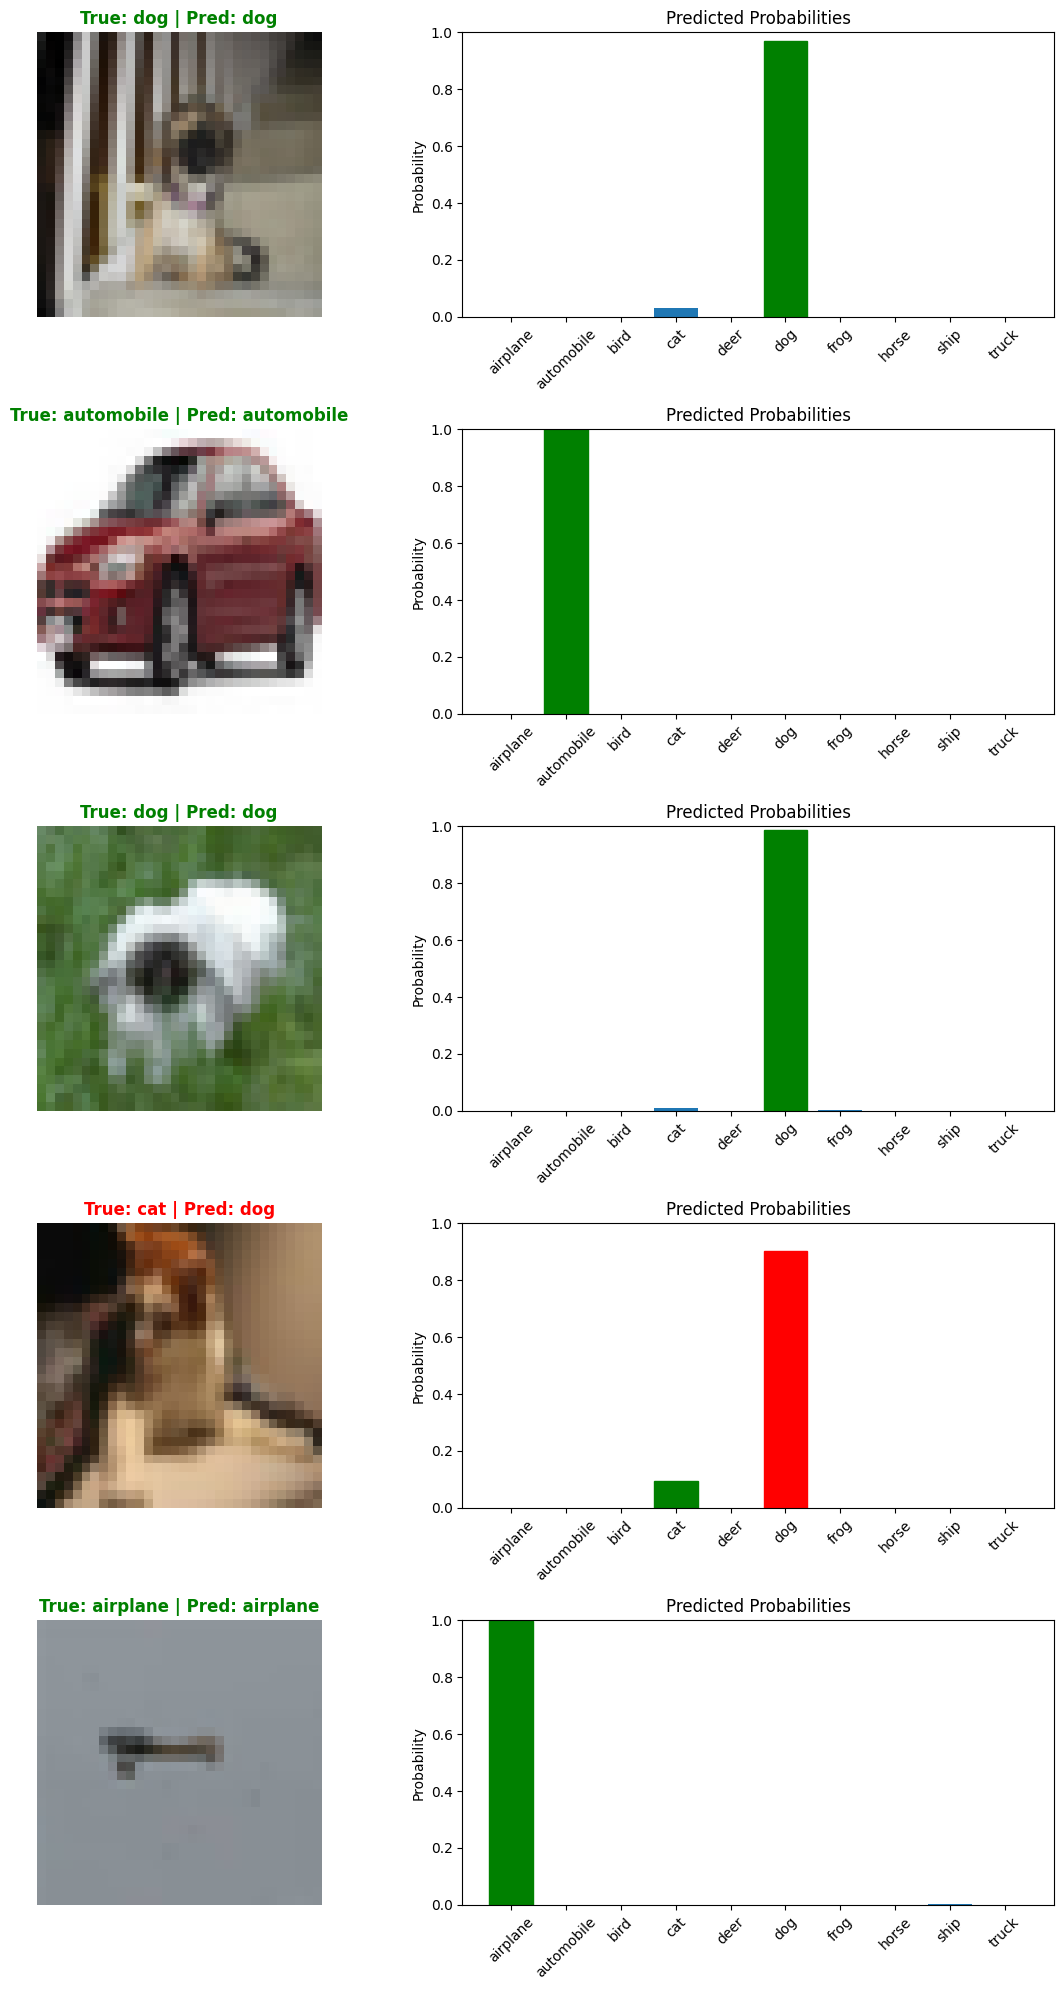


Testing prediction accuracy on 100 random samples...
Sample prediction accuracy: 96/100 = 96.00%


In [12]:
labels = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Test multiple random predictions
num_predictions = 5

fig, axes = plt.subplots(num_predictions, 2, figsize=(12, 4 * num_predictions))

for i in range(num_predictions):
    idx = np.random.randint(len(X_test))
    image = X_test[idx]
    true_label = y_test[idx]

    # Preprocess the image before prediction
    image_preprocessed = preprocess_input(image.copy())
    probs = model.predict(image_preprocessed[np.newaxis, ...], verbose=0)[0]
    pred_label = np.argmax(probs)

    # Image display
    axes[i, 0].imshow(image)
    axes[i, 0].axis("off")
    color = "green" if pred_label == true_label else "red"
    axes[i, 0].set_title(
        f"True: {labels[true_label]} | Pred: {labels[pred_label]}",
        color=color,
        fontweight='bold'
    )

    # Probability bar chart
    bars = axes[i, 1].bar(labels, probs)
    axes[i, 1].tick_params(axis='x', rotation=45)
    axes[i, 1].set_ylim(0, 1)
    axes[i, 1].set_ylabel('Probability')
    bars[pred_label].set_color("red")
    bars[true_label].set_color("green")
    axes[i, 1].set_title("Predicted Probabilities")

plt.tight_layout()
plt.show()

## Calculate overall accuracy on sample predictions
print("\nTesting prediction accuracy on 100 random samples...")
correct = 0
total = 100

for _ in range(total):
    idx = np.random.randint(len(X_test))
    image = X_test[idx]
    true_label = y_test[idx]
    
    image_preprocessed = preprocess_input(image.copy())
    probs = model.predict(image_preprocessed[np.newaxis, ...], verbose=0)[0]
    pred_label = np.argmax(probs)
    
    if pred_label == true_label:
        correct += 1

print(f"Sample prediction accuracy: {correct}/{total} = {correct/total:.2%}")